# Afferent Clustering Sweep — Real Units (96 K snippets, 10 units)

**Goal:** Evaluate how well the population-code afferent activations separate
putative units identified by OSort, using the new **KNN purity** metric
(K = 1, 5, 10, 20) alongside matched accuracy, ARI, NMI, cluster purity,
and silhouette.

**Pipeline:**
1. Load the curated real-unit dataset (96 006 snippets, 64 samples each)
2. Validate class / unit distributions
3. Build Tier-3 feature matrices
4. Run `run_afferent_clustering_benchmark` (fits WeightBank → projects → KMeans → scores)
5. Visualise KNN purity curves, cluster quality heatmaps, and per-unit statistics

In [1]:
# ── Imports & project root ──────────────────────────────────────────────────
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from spike_discrim.features.extraction import build_feature_matrix
from spike_discrim.input_layer.weights import WeightBank
from spike_discrim.io.storage import load_waveforms, make_run_dir
from spike_discrim.metrics.evaluation import knn_purity, knn_purity_sweep
from spike_discrim.benchmarking.afferent_clustering import run_afferent_clustering_benchmark

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})
print(f"Project root: {PROJECT_ROOT}")
print("Imports OK ✓")

Project root: /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim
Imports OK ✓


## 1 · Load the curated real-unit dataset

In [2]:
# ── Load waveforms + labels ─────────────────────────────────────────────────
WAVEFORM_PATH = PROJECT_ROOT / "data" / "real_units" / "waveforms_real.npz"
META_PATH     = PROJECT_ROOT / "data" / "real_units" / "waveforms_real_meta.csv"

loaded       = load_waveforms(WAVEFORM_PATH)
waveforms    = loaded["waveforms"].astype(np.float32)
class_labels = loaded["class_labels"].astype(np.int32)
unit_ids     = loaded["unit_ids"].astype(np.int32)
meta_df      = pd.read_csv(META_PATH)

print(f"Waveforms   : {waveforms.shape}  (N snippets × T samples)")
print(f"Class labels: {np.unique(class_labels, return_counts=True)}")
print(f"Unit IDs    : {np.unique(unit_ids)}")
print(f"Meta columns: {list(meta_df.columns)}")

Waveforms   : (96006, 64)  (N snippets × T samples)
Class labels: (array([0, 1], dtype=int32), array([57861, 38145]))
Unit IDs    : [ 0  1  2  3  4  5  6  7  8  9 10]
Meta columns: ['source_file', 'cluster_id', 'label', 'unit_id', 'timestamp_s']


## 2 · Dataset validation — class balance & per-unit spike counts

In [3]:
# ── Per-unit spike counts table ─────────────────────────────────────────────
spike_mask = (class_labels == 1) & (unit_ids > 0)
noise_mask = class_labels == 0

print(f"Total snippets : {len(class_labels):,}")
print(f"Noise events   : {noise_mask.sum():,}  ({100*noise_mask.mean():.1f}%)")
print(f"Spike events   : {spike_mask.sum():,}  ({100*spike_mask.mean():.1f}%)")
print(f"Unique units   : {len(np.unique(unit_ids[spike_mask]))}\n")

# Build a tidy table
unit_counts = (
    pd.DataFrame({"unit_id": unit_ids[spike_mask]})
    .groupby("unit_id")
    .size()
    .reset_index(name="n_spikes")
    .sort_values("n_spikes", ascending=False)
)
unit_counts["pct_of_spikes"] = (100 * unit_counts["n_spikes"] / unit_counts["n_spikes"].sum()).round(1)
display(unit_counts.reset_index(drop=True))

Total snippets : 96,006
Noise events   : 57,861  (60.3%)
Spike events   : 38,145  (39.7%)
Unique units   : 10



,unit_id,n_spikes,pct_of_spikes
0,8,15057,39.5
1,5,5914,15.5
2,6,3539,9.3
3,3,3493,9.2
4,10,2979,7.8
5,2,2557,6.7
6,7,2175,5.7
7,1,982,2.6
8,9,742,1.9
9,4,707,1.9


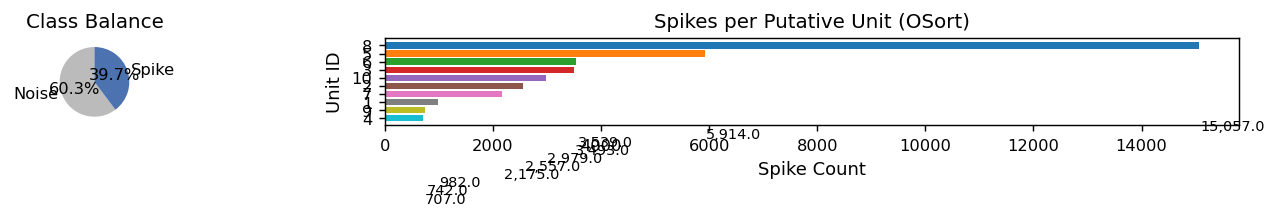

In [4]:
# ── Visual: class balance + per-unit bar chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), gridspec_kw={"width_ratios": [1, 2.2]})

# Left — pie chart: noise vs spike
counts = [noise_mask.sum(), spike_mask.sum()]
axes[0].pie(counts, labels=["Noise", "Spike"], autopct="%1.1f%%",
            colors=["#bbb", "#4c72b0"], startangle=90, textprops={"fontsize": 9})
axes[0].set_title("Class Balance")

# Right — bar chart: spikes per unit
colours = plt.cm.tab10(np.linspace(0, 1, len(unit_counts)))
axes[1].barh(unit_counts["unit_id"].astype(str), unit_counts["n_spikes"], color=colours)
axes[1].set_xlabel("Spike Count")
axes[1].set_ylabel("Unit ID")
axes[1].set_title("Spikes per Putative Unit (OSort)")
for i, row in unit_counts.iterrows():
    axes[1].text(row["n_spikes"] + 30, str(row["unit_id"]),
                 f'{row["n_spikes"]:,}', va="center", fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fig_unit_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Mean waveform overlay per unit

Quick sanity check: do the OSort-labelled units actually look like distinct waveform morphologies?

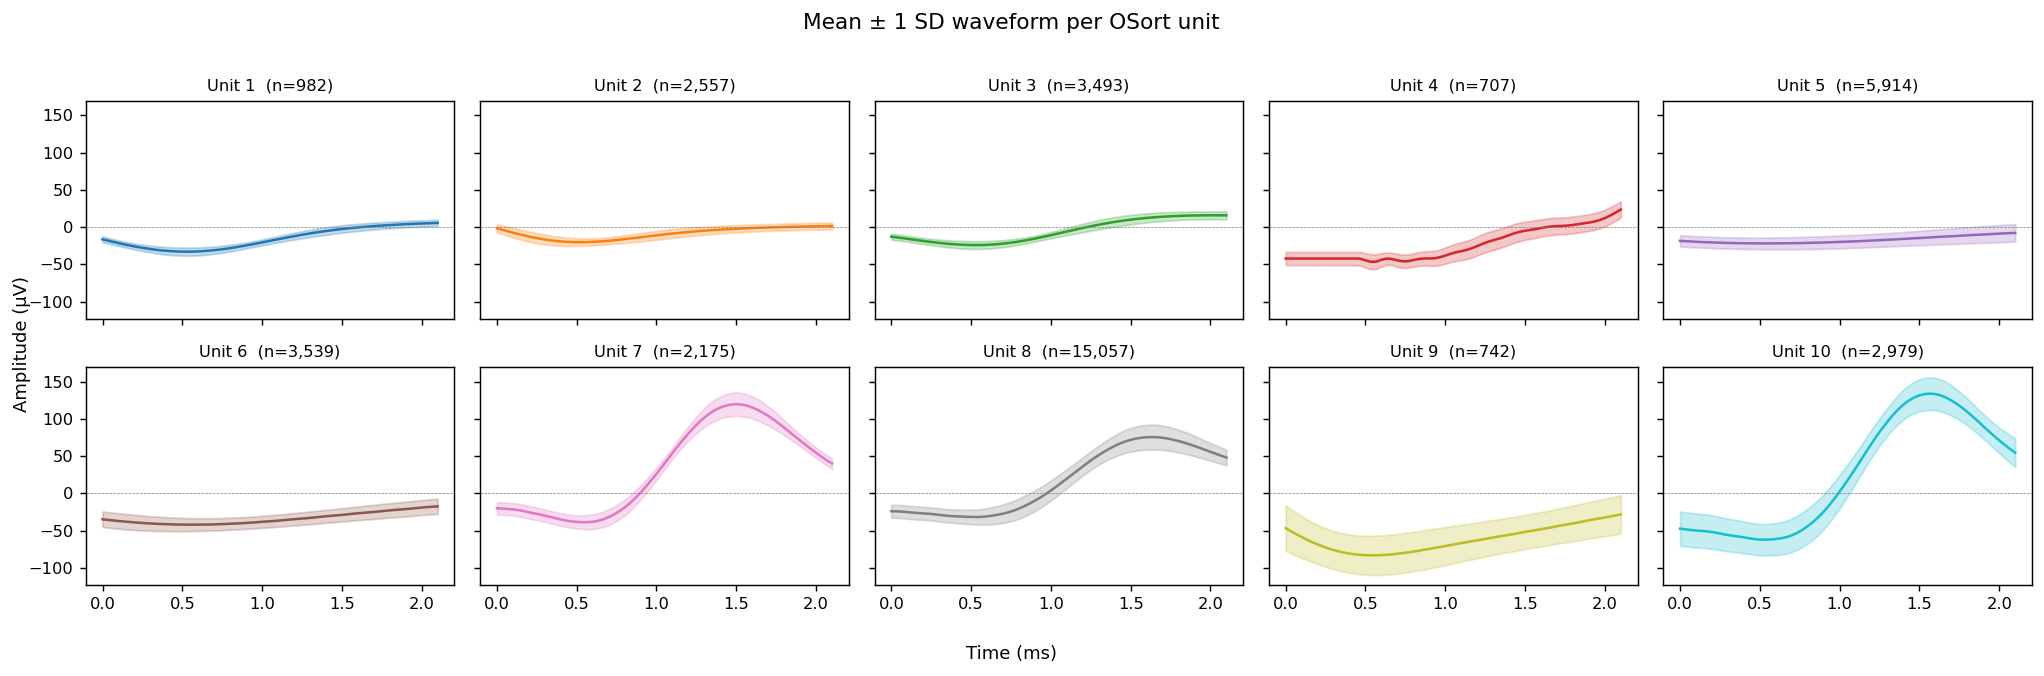

In [5]:
# ── Mean ± std waveform per unit ────────────────────────────────────────────
unique_units = np.sort(np.unique(unit_ids[spike_mask]))
n_units = len(unique_units)
cols = min(5, n_units)
rows = int(np.ceil(n_units / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 2.5 * rows), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).ravel()
time_axis = np.arange(waveforms.shape[1]) / 30.0  # ms at 30 kHz

for idx, uid in enumerate(unique_units):
    ax = axes_flat[idx]
    w = waveforms[(unit_ids == uid) & spike_mask]
    mu, sd = w.mean(axis=0), w.std(axis=0)
    ax.fill_between(time_axis, mu - sd, mu + sd, alpha=0.25, color=f"C{idx}")
    ax.plot(time_axis, mu, color=f"C{idx}", lw=1.4)
    ax.set_title(f"Unit {uid}  (n={len(w):,})", fontsize=9)
    ax.axhline(0, color="grey", lw=0.4, ls="--")

for idx in range(n_units, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.supxlabel("Time (ms)", fontsize=10)
fig.supylabel("Amplitude (µV)", fontsize=10)
fig.suptitle("Mean ± 1 SD waveform per OSort unit", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fig_mean_waveforms.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Build Tier-3 feature matrix

Extract all 3 tiers of features (scalar + temporal MAD + event-based) at the default temporal bin count.

In [6]:
# ── Feature extraction (Tier 3 = scalar + temporal MAD + event) ─────────────
FEATURE_TIER = 3
N_TIME_BINS  = 8   # default; the sweep below will test more

feature_cfg = {
    "temporal_mad": {
        "enabled": True,
        "n_time_bins": N_TIME_BINS,
    },
}

feature_matrix, feature_names, feat_meta = build_feature_matrix(
    waveforms, cfg=feature_cfg, tier=FEATURE_TIER,
)
print(f"Feature matrix : {feature_matrix.shape}  ({len(feature_names)} features)")
print(f"Features       : {feature_names}")
print(f"NaN check      : {np.isnan(feature_matrix).sum()} NaN values")

Feature matrix : (96006, 26)  (26 features)
Features       : ['peak_amplitude', 'trough_amplitude', 'max_slope', 'min_slope', 'max_abs_curvature', 'abs_window_sum_peak', 'mad_wta_bin_00', 'mad_wta_bin_01', 'mad_wta_bin_02', 'mad_wta_bin_03', 'mad_wta_bin_04', 'mad_wta_bin_05', 'mad_wta_bin_06', 'mad_wta_bin_07', 'ev_trough_amplitude', 'ev_peak_amplitude', 'ev_trough_to_peak_time_samples', 'ev_half_width_samples', 'ev_full_width_samples', 'ev_biphasic_ratio', 'ev_signed_area', 'ev_absolute_area', 'ev_max_rising_slope', 'ev_max_falling_slope', 'ev_baseline_rms', 'ev_zero_crossing_count']
NaN check      : 0 NaN values


## 5 · Run the afferent clustering benchmark

This calls `run_afferent_clustering_benchmark` which:
1. Filters to spikes only (`class_label == 1, unit_id > 0`)
2. Fits a **WeightBank** (Gaussian population code) on the spike features
3. Projects into afferent activation space
4. Splits features into 4 families (scalar, temporal_mad, event, full)
5. Runs **KMeans** per family and scores with ARI, NMI, matched accuracy, purity, silhouette
6. Computes **KNN purity** at K = 1, 5, 10, 20 on the afferent activations

In [7]:
# ── Clustering benchmark on real data ───────────────────────────────────────
RESULTS_DIR = make_run_dir(base_dir=str(PROJECT_ROOT / "data" / "results"))
print(f"Results will be saved to: {RESULTS_DIR}\n")

cluster_df = run_afferent_clustering_benchmark(
    feature_matrix=feature_matrix,
    class_labels=class_labels,
    unit_ids=unit_ids,
    feature_names=feature_names,
    results_dir=RESULTS_DIR,
    n_bins=10,
    sigma_scale=1.0,
    threshold=0.5,
    clustering_cfg={
        "enabled": True,
        "n_clusters": None,   # auto = number of unique units
        "random_seed": 42,
        "n_init": 10,
        "max_iter": 300,
        "save_outputs": True,
    },
    verbose=True,
)

print(f"\n{'='*70}")
print(f"Clustering complete — {len(cluster_df)} families evaluated")
print(f"Results saved to {RESULTS_DIR}")

Results will be saved to: /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim/data/results/20260407_075152

  Afferent clustering: scalar (60 dims)
  Afferent clustering: temporal_mad (80 dims)
  Afferent clustering: event (120 dims)
  Afferent clustering: full (260 dims)

Clustering complete — 4 families evaluated
Results saved to /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim/data/results/20260407_075152


## 6 · Results table — all families, all metrics

In [8]:
# ── Display the full results table ──────────────────────────────────────────
display_cols = [
    "rank", "family", "n_input_features", "flat_dim",
    "matched_accuracy", "ari", "nmi", "purity", "silhouette",
    "knn_purity_k01", "knn_purity_k05", "knn_purity_k10", "knn_purity_k20",
]
cols_present = [c for c in display_cols if c in cluster_df.columns]
styled = (
    cluster_df[cols_present]
    .style
    .format({c: "{:.4f}" for c in cols_present if c not in ("rank", "family", "n_input_features", "flat_dim")})
    .background_gradient(subset=[c for c in cols_present if "knn_purity" in c], cmap="YlGn")
    .background_gradient(subset=["matched_accuracy"], cmap="YlGn")
    .set_caption("Afferent Clustering Benchmark — Real Units")
)
display(styled)

,rank,family,n_input_features,flat_dim,matched_accuracy,ari,nmi,purity,silhouette,knn_purity_k01,knn_purity_k05,knn_purity_k10,knn_purity_k20
0,1,event,12,120,0.5426,0.3665,0.6275,0.7645,0.1376,0.9575,0.9504,0.9453,0.9382
1,2,scalar,6,60,0.5406,0.3974,0.6518,0.8108,0.1888,0.9194,0.9123,0.9082,0.9031
2,3,full,26,260,0.5365,0.4046,0.6708,0.8190,0.1407,0.9638,0.9572,0.9531,0.9472
3,4,temporal_mad,8,80,0.4301,0.3125,0.5407,0.6991,0.1373,0.8482,0.8367,0.8288,0.8181


## 7 · KNN purity sweep curve (K = 1, 5, 10, 20)

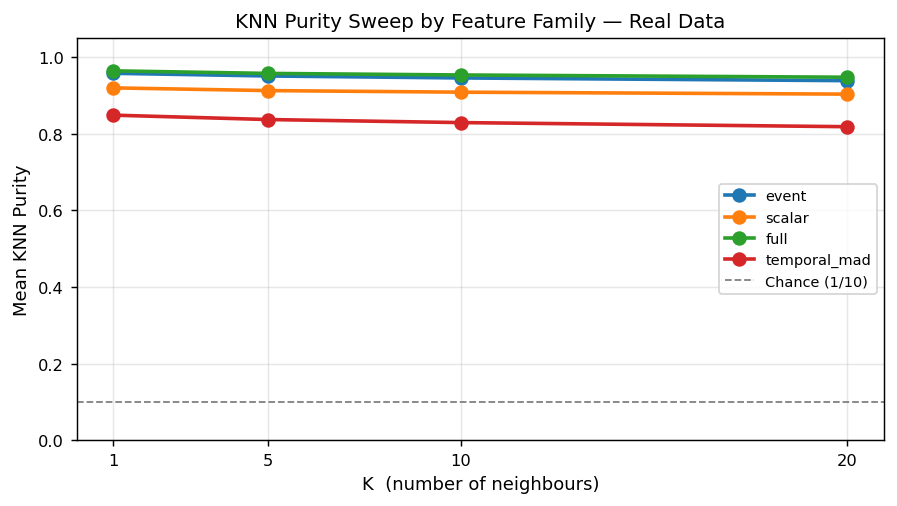

In [9]:
# ── KNN purity vs K — one line per feature family ──────────────────────────
k_cols = ["knn_purity_k01", "knn_purity_k05", "knn_purity_k10", "knn_purity_k20"]
k_vals = [1, 5, 10, 20]

fig, ax = plt.subplots(figsize=(7, 4))
for _, row in cluster_df.iterrows():
    purities = [row[c] for c in k_cols]
    ax.plot(k_vals, purities, "o-", label=row["family"], lw=2, markersize=7)

# Chance line: 1/n_units
n_units_real = cluster_df["n_units"].iloc[0]
ax.axhline(1.0 / n_units_real, color="grey", ls="--", lw=1, label=f"Chance (1/{n_units_real})")

ax.set_xlabel("K  (number of neighbours)")
ax.set_ylabel("Mean KNN Purity")
ax.set_title("KNN Purity Sweep by Feature Family — Real Data")
ax.set_xticks(k_vals)
ax.set_ylim(0, 1.05)
ax.legend(loc="best", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fig_knn_purity_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 · Cluster quality heatmap (all metrics × families)

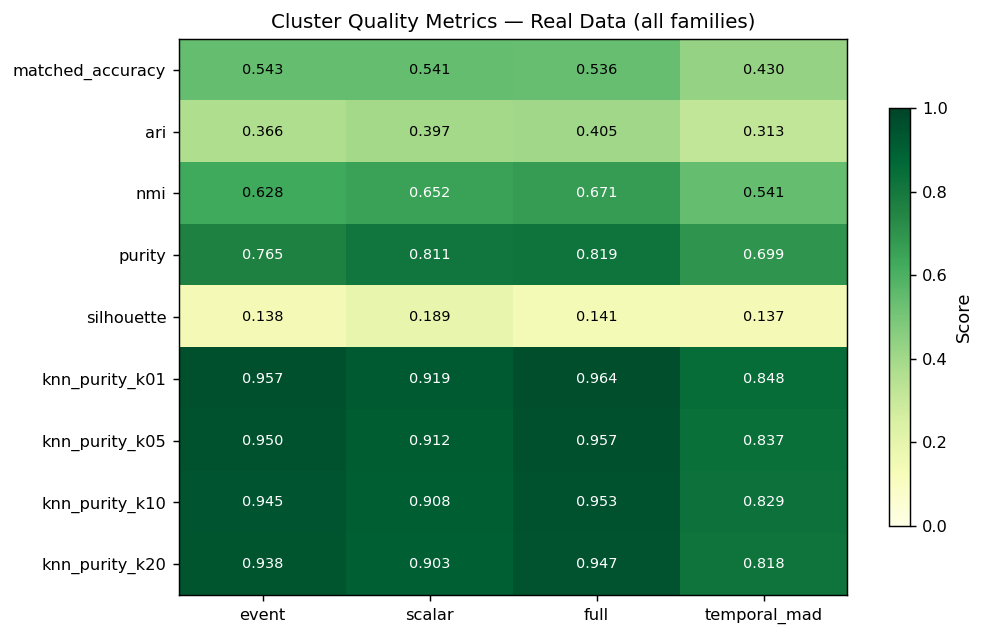

In [10]:
# ── Heatmap: metric × family ────────────────────────────────────────────────
metric_cols = ["matched_accuracy", "ari", "nmi", "purity", "silhouette",
               "knn_purity_k01", "knn_purity_k05", "knn_purity_k10", "knn_purity_k20"]
metric_cols = [c for c in metric_cols if c in cluster_df.columns]

heat_data = cluster_df.set_index("family")[metric_cols].T

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat_data.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, fontsize=9)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=9)

# Annotate cells
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data.values[i, j]
        colour = "white" if val > 0.65 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8, color=colour)

fig.colorbar(im, ax=ax, shrink=0.75, label="Score")
ax.set_title("Cluster Quality Metrics — Real Data (all families)", fontsize=11)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fig_cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Per-unit KNN purity breakdown (best family)

For the top-ranked family, compute KNN purity **per unit** to see which units are easiest / hardest to separate.

In [11]:
# ── Per-unit KNN purity for the best family ────────────────────────────────
from sklearn.neighbors import NearestNeighbors

best_family = cluster_df.iloc[0]["family"]
afferent_path = Path(RESULTS_DIR) / "afferent_outputs" / f"{best_family}.npz"
aff = np.load(afferent_path)
X_aff = aff["afferent_outputs"]
y_aff = aff["unit_ids"]

K_VALS = [1, 5, 10, 20]
per_unit_rows = []

for k in K_VALS:
    nn = NearestNeighbors(n_neighbors=k + 1, algorithm="auto")
    nn.fit(X_aff)
    nbr_idx = nn.kneighbors(X_aff, return_distance=False)[:, 1:]
    nbr_labels = y_aff[nbr_idx]
    matches = (nbr_labels == y_aff[:, np.newaxis]).sum(axis=1) / k  # per-sample purity

    for uid in np.sort(np.unique(y_aff)):
        mask = y_aff == uid
        per_unit_rows.append({
            "unit_id": int(uid),
            "K": k,
            "n_spikes": int(mask.sum()),
            "mean_purity": float(matches[mask].mean()),
            "std_purity": float(matches[mask].std()),
            "min_purity": float(matches[mask].min()),
        })

per_unit_df = pd.DataFrame(per_unit_rows)

# Pivot for nice display
pivot = per_unit_df.pivot_table(index="unit_id", columns="K", values="mean_purity")
pivot.columns = [f"K={k}" for k in pivot.columns]
pivot["n_spikes"] = per_unit_df.groupby("unit_id")["n_spikes"].first().values

print(f"Best family: {best_family}")
display(
    pivot.style
    .format({c: "{:.4f}" for c in pivot.columns if c.startswith("K=")})
    .format({"n_spikes": "{:,}"})
    .background_gradient(subset=[c for c in pivot.columns if c.startswith("K=")], cmap="YlGn", vmin=0, vmax=1)
    .set_caption(f"Per-Unit KNN Purity — {best_family} family")
)

Best family: event


,K=1,K=5,K=10,K=20,n_spikes
unit_id,,,,,
1,0.885947,0.875967,0.862118,0.842821,982
2,0.972233,0.967931,0.961283,0.950743,"2,557"
3,0.967363,0.966619,0.964300,0.961609,"3,493"
4,0.964639,0.949364,0.942716,0.933098,707
5,0.900237,0.887792,0.877629,0.866241,"5,914"
6,0.886691,0.881322,0.877932,0.873241,"3,539"
7,0.975632,0.961287,0.951448,0.938828,"2,175"
8,0.995285,0.991964,0.990337,0.987272,"15,057"
9,0.901617,0.894340,0.879919,0.855256,742


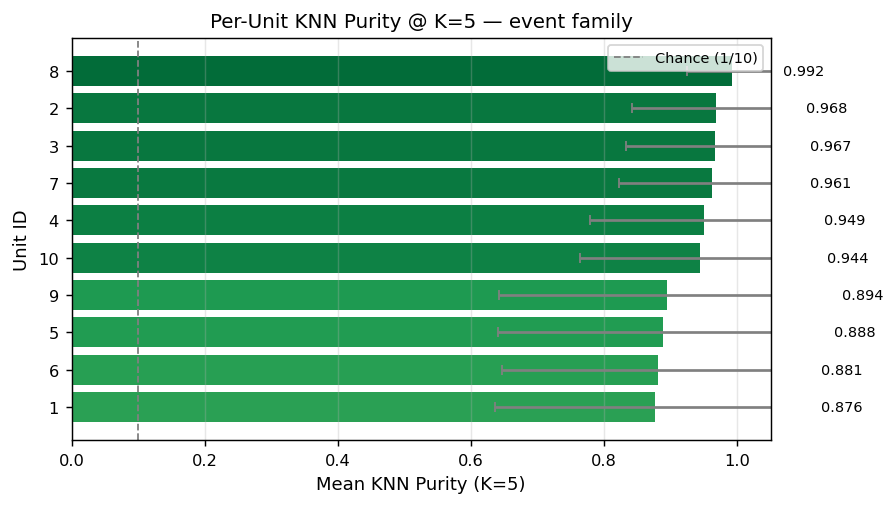

In [12]:
# ── Visual: per-unit KNN purity bar chart at K=5 ───────────────────────────
k5_data = per_unit_df[per_unit_df["K"] == 5].sort_values("mean_purity", ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colours = plt.cm.RdYlGn(k5_data["mean_purity"].values)
bars = ax.barh(k5_data["unit_id"].astype(str), k5_data["mean_purity"], color=colours,
               xerr=k5_data["std_purity"], capsize=3, ecolor="grey")
ax.axvline(1.0 / n_units_real, color="grey", ls="--", lw=1, label=f"Chance (1/{n_units_real})")
ax.set_xlabel("Mean KNN Purity (K=5)")
ax.set_ylabel("Unit ID")
ax.set_title(f"Per-Unit KNN Purity @ K=5 — {best_family} family")
ax.set_xlim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)

for bar, (_, row) in zip(bars, k5_data.iterrows()):
    ax.text(row["mean_purity"] + row["std_purity"] + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{row["mean_purity"]:.3f}', va="center", fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fig_per_unit_knn_purity.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 · Confusion-style matrix: KMeans cluster vs true unit (best family)

Cluster-to-Unit contingency table — event family


unit_id,1,2,3,4,5,6,7,8,9,10,Total
cluster_id,,,,,,,,,,,
0,45,1168,15,46,227,25,0,4,24,4,1558
1,0,0,0,1,0,2,24,2839,1,1281,4148
2,34,77,0,0,3995,51,0,0,0,0,4157
3,0,0,4,2,15,2,0,4633,0,0,4656
4,0,0,0,0,0,0,4,3398,0,16,3418
5,26,292,3276,4,87,1,0,1,0,0,3687
6,0,0,2,0,1,0,0,3363,1,0,3367
7,0,0,0,2,0,0,2147,818,5,1678,4650
8,3,0,0,5,786,3323,0,0,587,0,4704


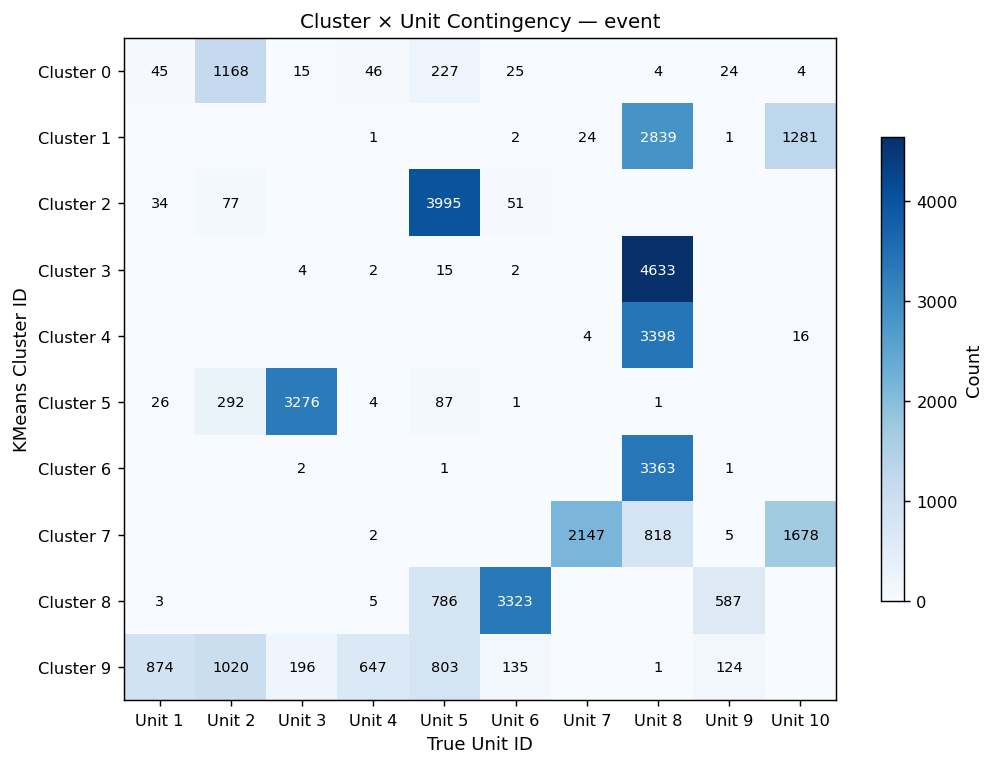

In [13]:
# ── Cluster–unit confusion matrix for the best family ──────────────────────
assign_path = Path(RESULTS_DIR) / "afferent_outputs" / f"{best_family}_assignments.parquet"
assign_df = pd.read_parquet(assign_path)

ct = pd.crosstab(assign_df["cluster_id"], assign_df["unit_id"],
                 margins=True, margins_name="Total")
print(f"Cluster-to-Unit contingency table — {best_family} family")
display(ct)

# Heatmap (without margins)
ct_core = pd.crosstab(assign_df["cluster_id"], assign_df["unit_id"])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ct_core.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(ct_core.columns)))
ax.set_xticklabels([f"Unit {c}" for c in ct_core.columns], fontsize=9)
ax.set_yticks(range(len(ct_core.index)))
ax.set_yticklabels([f"Cluster {c}" for c in ct_core.index], fontsize=9)
ax.set_xlabel("True Unit ID")
ax.set_ylabel("KMeans Cluster ID")
ax.set_title(f"Cluster × Unit Contingency — {best_family}")

for i in range(ct_core.shape[0]):
    for j in range(ct_core.shape[1]):
        v = ct_core.values[i, j]
        if v > 0:
            colour = "white" if v > ct_core.values.max() * 0.6 else "black"
            ax.text(j, i, str(v), ha="center", va="center", fontsize=8, color=colour)

fig.colorbar(im, ax=ax, shrink=0.7, label="Count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fig_cluster_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Export summary for `clustering_results.md`

In [14]:
# ── Build markdown report string ────────────────────────────────────────────
from datetime import datetime

n_spikes = int(cluster_df.iloc[0]["n_events"])
n_units_val = int(cluster_df.iloc[0]["n_units"])

# Family results table
fam_header = "| Rank | Family | Dims | Matched Acc | ARI | NMI | Purity | Silhouette | KNN-k1 | KNN-k5 | KNN-k10 | KNN-k20 |"
fam_sep    = "|------|--------|------|-------------|-----|-----|--------|------------|--------|--------|---------|---------|"
fam_rows = []
for _, r in cluster_df.iterrows():
    fam_rows.append(
        f"| {int(r['rank'])} | {r['family']} | {int(r['flat_dim'])} "
        f"| {r['matched_accuracy']:.4f} | {r['ari']:.4f} | {r['nmi']:.4f} "
        f"| {r['purity']:.4f} | {r['silhouette']:.4f} "
        f"| {r['knn_purity_k01']:.4f} | {r['knn_purity_k05']:.4f} "
        f"| {r['knn_purity_k10']:.4f} | {r['knn_purity_k20']:.4f} |"
    )

# Per-unit table (K=5)
k5_all = per_unit_df[per_unit_df["K"] == 5].sort_values("unit_id")
unit_header = "| Unit ID | Spikes | Mean Purity (K=5) | Std | Min |"
unit_sep    = "|---------|--------|-------------------|-----|-----|"
unit_rows = []
for _, r in k5_all.iterrows():
    unit_rows.append(
        f"| {int(r['unit_id'])} | {int(r['n_spikes']):,} "
        f"| {r['mean_purity']:.4f} | {r['std_purity']:.4f} | {r['min_purity']:.4f} |"
    )

md = f"""# Afferent Clustering Results — Real Units

**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M')}
**Dataset:** `data/real_units/waveforms_real.npz` — {len(class_labels):,} total snippets
**Spike events used for clustering:** {n_spikes:,}
**Putative units (OSort):** {n_units_val}
**Feature tier:** 3 (scalar + temporal MAD + event-based)
**WeightBank config:** n_bins=10, sigma_scale=1.0, threshold=0.5
**Clustering:** KMeans (n_clusters={n_units_val}, n_init=10, seed=42)
**Results directory:** `{RESULTS_DIR}`

---

## Metric Definitions

| Metric | Description |
|--------|-------------|
| **Matched Accuracy** | Best cluster↔unit assignment via Hungarian algorithm |
| **ARI** | Adjusted Rand Index (chance-corrected) |
| **NMI** | Normalised Mutual Information |
| **Purity** | Fraction of each cluster belonging to dominant unit |
| **Silhouette** | Mean silhouette coefficient of KMeans clusters |
| **KNN Purity (K=k)** | For each spike, fraction of k nearest neighbours in afferent space sharing the same unit label |

---

## Family-Level Results

{fam_header}
{fam_sep}
{chr(10).join(fam_rows)}

---

## Per-Unit KNN Purity (Best Family: `{best_family}`)

{unit_header}
{unit_sep}
{chr(10).join(unit_rows)}

---

## Figures

| Figure | Description |
|--------|-------------|
| ![Unit Distribution](fig_unit_distribution.png) | Class balance and per-unit spike counts |
| ![Mean Waveforms](fig_mean_waveforms.png) | Mean ± 1 SD waveform per OSort unit |
| ![KNN Purity Sweep](fig_knn_purity_sweep.png) | KNN purity vs K for each feature family |
| ![Cluster Heatmap](fig_cluster_heatmap.png) | All metrics × families heatmap |
| ![Per-Unit Purity](fig_per_unit_knn_purity.png) | Per-unit KNN purity at K=5 |
| ![Confusion Matrix](fig_cluster_confusion.png) | KMeans cluster vs true unit contingency |

---

## Interpretation

- **KNN purity** directly measures whether the afferent population-code
  representation preserves unit identity in its local neighbourhood structure.
  A purity of *p* at K=5 means that, on average, {int(5)}×*p* of a spike's
  5 nearest neighbours in activation space belong to the same neuron.

- Values **well above chance (1/{n_units_val} = {1/n_units_val:.3f})** indicate
  that the afferent encoding creates a geometry where same-unit spikes are
  clustered together — a prerequisite for any downstream competitive-learning
  or WTA spiking layer.

- The **per-unit breakdown** reveals which neurons are hardest to separate,
  guiding future work on feature engineering or per-channel normalisation.
"""

# Write to docs/
md_path = PROJECT_ROOT / "docs" / "clustering_results.md"
md_path.write_text(md)
print(f"Report written to {md_path}")
print(f"Report length: {len(md):,} characters")

Report written to /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim/docs/clustering_results.md
Report length: 3,549 characters
